# Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from geopy.geocoders import Nominatim
import plotly.express as px


from pandas.tseries.holiday import USFederalHolidayCalendar

from sklearn.preprocessing import OneHotEncoder, TargetEncoder, StandardScaler
from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score 

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
    
import warnings
warnings.filterwarnings("ignore")   

# Load Data

In [2]:
data = pd.read_csv("cab_rides.csv")

print("Dataset Shape:", data.shape)
data.head()

Dataset Shape: (693071, 10)


,distance,cab_type,time_stamp,destination,source,price,surge_multiplier,id,product_id,name
0,0.44,Lyft,1544952607890,North Station,Haymarket Square,5.0,1.0,424553bb-7174-41ea-aeb4-fe06d4f4b9d7,lyft_line,Shared
1,0.44,Lyft,1543284023677,North Station,Haymarket Square,11.0,1.0,4bd23055-6827-41c6-b23b-3c491f24e74d,lyft_premier,Lux
2,0.44,Lyft,1543366822198,North Station,Haymarket Square,7.0,1.0,981a3613-77af-4620-a42a-0c0866077d1e,lyft,Lyft
3,0.44,Lyft,1543553582749,North Station,Haymarket Square,26.0,1.0,c2d88af2-d278-4bfd-a8d0-29ca77cc5512,lyft_luxsuv,Lux Black XL
4,0.44,Lyft,1543463360223,North Station,Haymarket Square,9.0,1.0,e0126e1f-8ca9-4f2e-82b3-50505a09db9a,lyft_plus,Lyft XL


# Explore Data

## Select 100,000 Records

In [3]:
data = data.iloc[:100000].copy()

print("Dataset Shape:", data.shape)

Dataset Shape: (100000, 10)


## Feature Understanding

In [4]:
data.head()

,distance,cab_type,time_stamp,destination,source,price,surge_multiplier,id,product_id,name
0,0.44,Lyft,1544952607890,North Station,Haymarket Square,5.0,1.0,424553bb-7174-41ea-aeb4-fe06d4f4b9d7,lyft_line,Shared
1,0.44,Lyft,1543284023677,North Station,Haymarket Square,11.0,1.0,4bd23055-6827-41c6-b23b-3c491f24e74d,lyft_premier,Lux
2,0.44,Lyft,1543366822198,North Station,Haymarket Square,7.0,1.0,981a3613-77af-4620-a42a-0c0866077d1e,lyft,Lyft
3,0.44,Lyft,1543553582749,North Station,Haymarket Square,26.0,1.0,c2d88af2-d278-4bfd-a8d0-29ca77cc5512,lyft_luxsuv,Lux Black XL
4,0.44,Lyft,1543463360223,North Station,Haymarket Square,9.0,1.0,e0126e1f-8ca9-4f2e-82b3-50505a09db9a,lyft_plus,Lyft XL


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   distance          100000 non-null  float64
 1   cab_type          100000 non-null  object 
 2   time_stamp        100000 non-null  int64  
 3   destination       100000 non-null  object 
 4   source            100000 non-null  object 
 5   price             92084 non-null   float64
 6   surge_multiplier  100000 non-null  float64
 7   id                100000 non-null  object 
 8   product_id        100000 non-null  object 
 9   name              100000 non-null  object 
dtypes: float64(3), int64(1), object(6)
memory usage: 7.6+ MB


In [6]:
data.describe()

,distance,time_stamp,price,surge_multiplier
count,100000.000000,1.000000e+05,92084.000000,100000.000000
mean,2.194748,1.544033e+12,16.577109,1.014978
std,1.138229,6.877724e+08,9.353030,0.094612
min,0.020000,1.543204e+12,2.500000,1.000000
25%,1.300000,1.543441e+12,9.000000,1.000000
50%,2.170000,1.543724e+12,13.500000,1.000000
75%,2.940000,1.544819e+12,22.500000,1.000000
max,7.500000,1.545161e+12,92.000000,3.000000


In [7]:
print("Missing Values:")
print(data.isnull().sum())

Missing Values:
distance               0
cab_type               0
time_stamp             0
destination            0
source                 0
price               7916
surge_multiplier       0
id                     0
product_id             0
name                   0
dtype: int64


In [8]:
print("\nDuplicate Rows:")
print(data.duplicated().sum())


Duplicate Rows:
0


In [9]:
# Descriptive Statistics
# Summarize the main numerical features.

data[
    ['distance', 'price', 'surge_multiplier']
].describe().T

,count,mean,std,min,25%,50%,75%,max
distance,100000.0,2.194748,1.138229,0.02,1.3,2.17,2.94,7.5
price,92084.0,16.577109,9.353030,2.50,9.0,13.50,22.50,92.0
surge_multiplier,100000.0,1.014978,0.094612,1.00,1.0,1.00,1.00,3.0


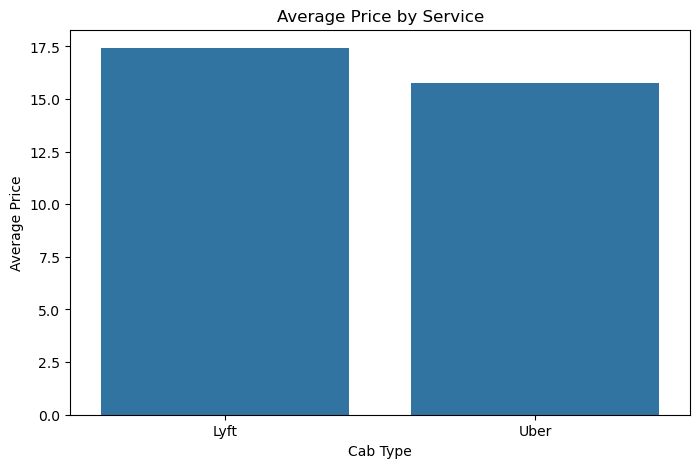

In [10]:
# Compare the average ride price between Uber and Lyft.

avg_price_by_cab = (
    data.groupby('cab_type')['price']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=avg_price_by_cab.index,
    y=avg_price_by_cab.values
)

plt.title('Average Price by Service')
plt.xlabel('Cab Type')
plt.ylabel('Average Price')

plt.show()

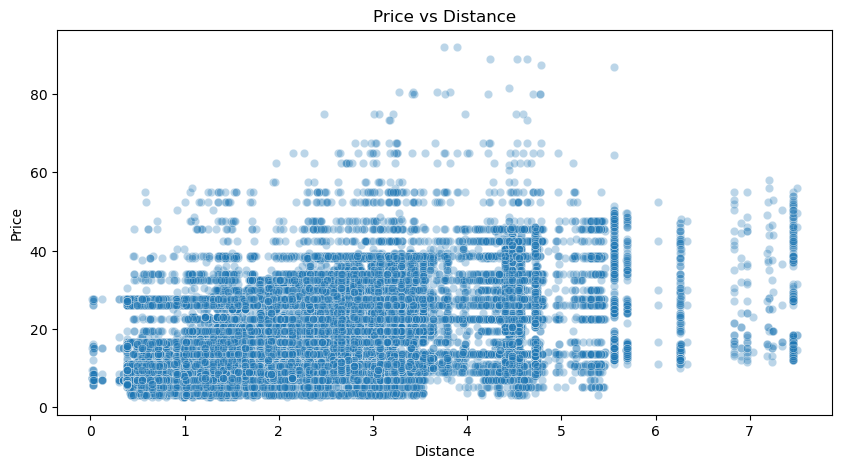

In [11]:
# Price vs Distance
# Examine the relationship between ride distance and price

plt.figure(figsize=(10, 5))

sns.scatterplot(
    data=data,
    x='distance',
    y='price',
    alpha=0.3
)

plt.title('Price vs Distance')
plt.xlabel('Distance')
plt.ylabel('Price')

plt.show()

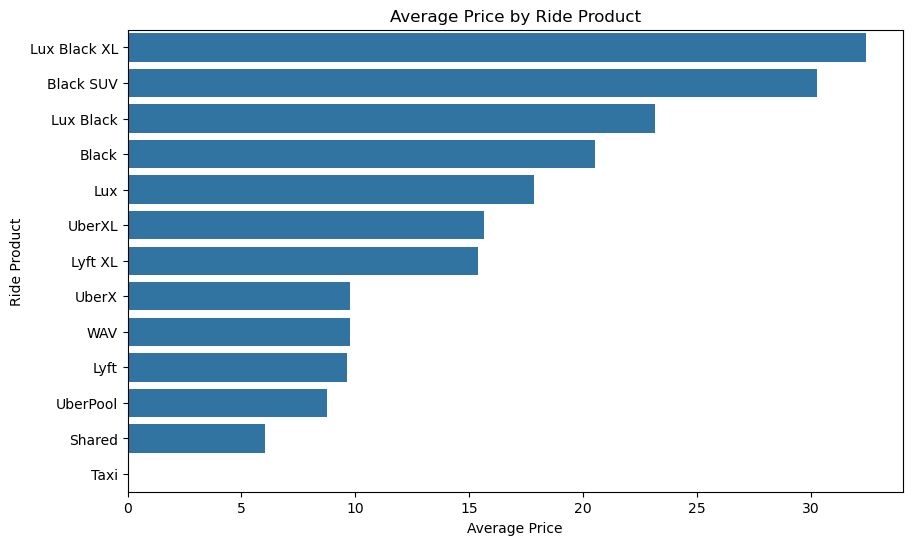

In [12]:
# Average Price by Ride Product
# Compare the average price across different ride products

avg_price_by_product = (
    data.groupby('name')['price']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=avg_price_by_product.values,
    y=avg_price_by_product.index
)

plt.title('Average Price by Ride Product')
plt.xlabel('Average Price')
plt.ylabel('Ride Product')

plt.show()

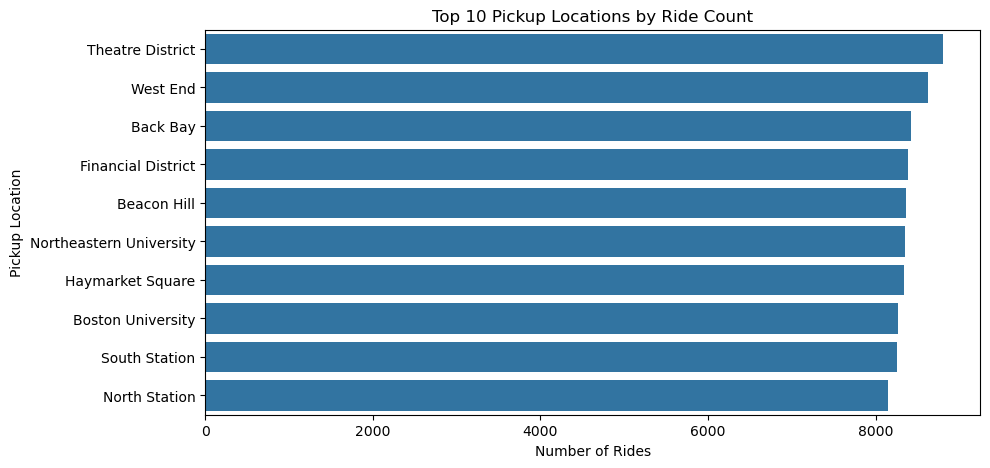

In [13]:
# Top 10 Pickup Locations
# Identify the most frequently recorded pickup locations
top_sources = data['source'].value_counts().head(10)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=top_sources.values,
    y=top_sources.index
)

plt.title('Top 10 Pickup Locations by Ride Count')
plt.xlabel('Number of Rides')
plt.ylabel('Pickup Location')

plt.show()

### Numerical Feature Visualization


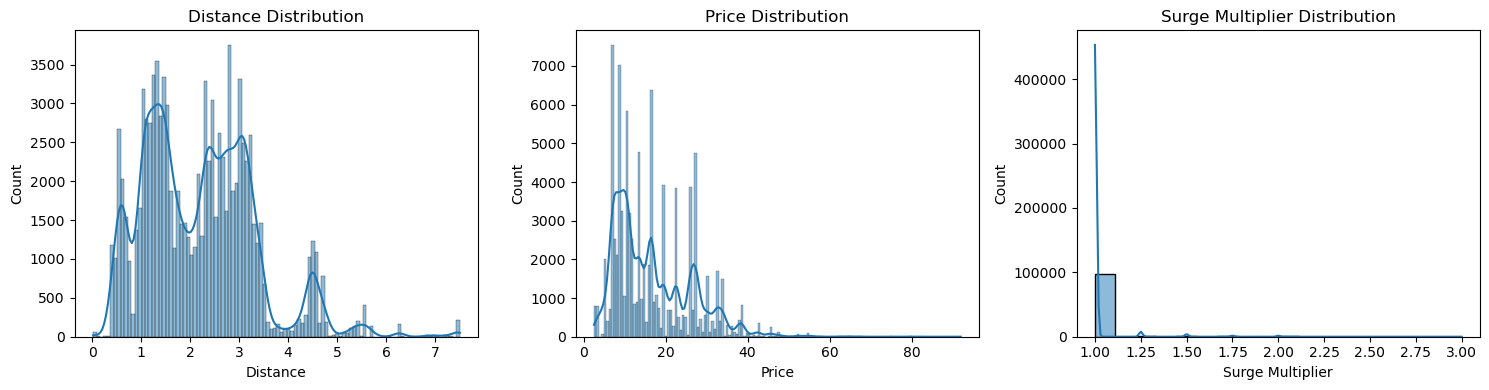

In [14]:
# Visualize the main numerical features to understand their distributions.

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(data['distance'], kde=True, ax=axes[0])
axes[0].set_title('Distance Distribution')
axes[0].set_xlabel('Distance')

sns.histplot(data['price'], kde=True, ax=axes[1])
axes[1].set_title('Price Distribution')
axes[1].set_xlabel('Price')

sns.histplot(data['surge_multiplier'], kde=True, ax=axes[2])
axes[2].set_title('Surge Multiplier Distribution')
axes[2].set_xlabel('Surge Multiplier')

plt.tight_layout()
plt.show()

#### What We Did

We visualized the distributions of the main numerical features:
distance, price, and surge multiplier.

This helps us understand the range and distribution of the numerical data

### Target Variable Visualization

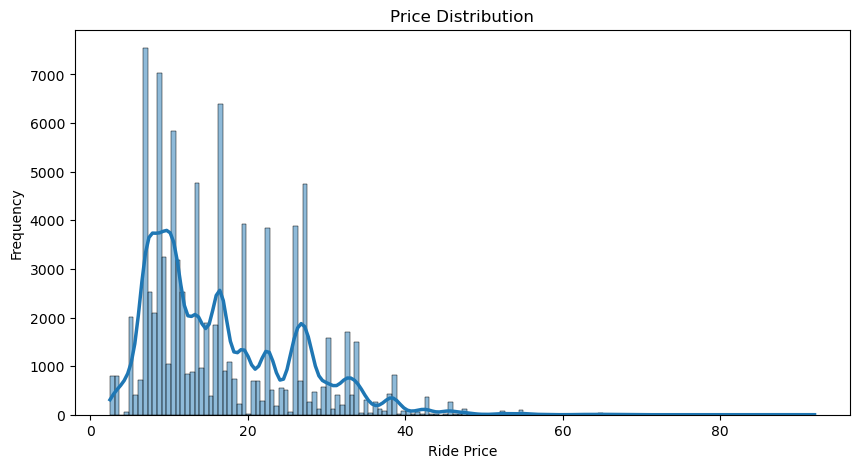

In [15]:
# Visualize the distribution of the ride price target.

plt.figure(figsize=(10, 5))

sns.histplot(
    data['price'],
    kde=True,
    line_kws={
        'color': 'red',
        'linewidth': 2.5
    }
)   

plt.title('Price Distribution')
plt.xlabel('Ride Price')
plt.ylabel('Frequency')

plt.show()

#### What We Did

We visualized the target variable, price, to understand its distribution
and identify whether the target contains skewness or extreme values

### Categorical Feature Visualization

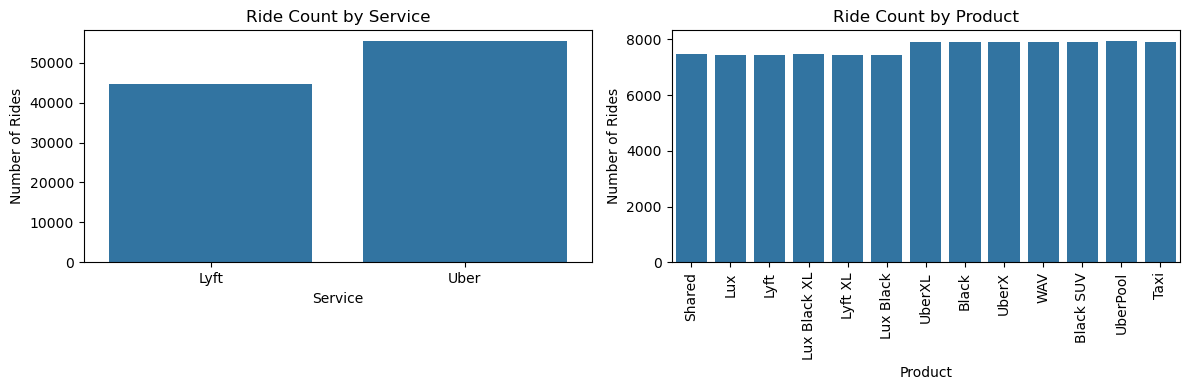

In [16]:
# Visualize the main categorical features in the dataset.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=data, x='cab_type', ax=axes[0])
axes[0].set_title('Ride Count by Service')
axes[0].set_xlabel('Service')
axes[0].set_ylabel('Number of Rides')

sns.countplot(data=data, x='name', ax=axes[1])
axes[1].set_title('Ride Count by Product')
axes[1].set_xlabel('Product')
axes[1].set_ylabel('Number of Rides')
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

#### What We Did

We visualized the main categorical features to understand the distribution
of rides across different services and ride products

### Correlation Heatmap


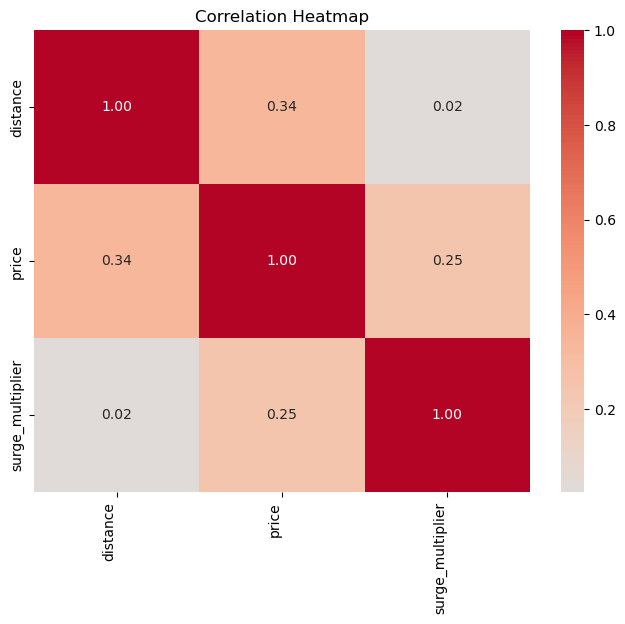

In [17]:
# Visualize correlations between the main numerical features and the target.

correlation_data = data[
    [
        'distance',
        'price',
        'surge_multiplier'
    ]
]

correlation_matrix = correlation_data.corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.xticks(rotation=90, ha='right')
plt.title('Correlation Heatmap')

plt.show()

#### What We Did

We created a correlation heatmap for the main numerical features
available in the original dataset.

This helps us understand the relationships between distance,
surge multiplier, and the target variable (price)

### Outlier Detection

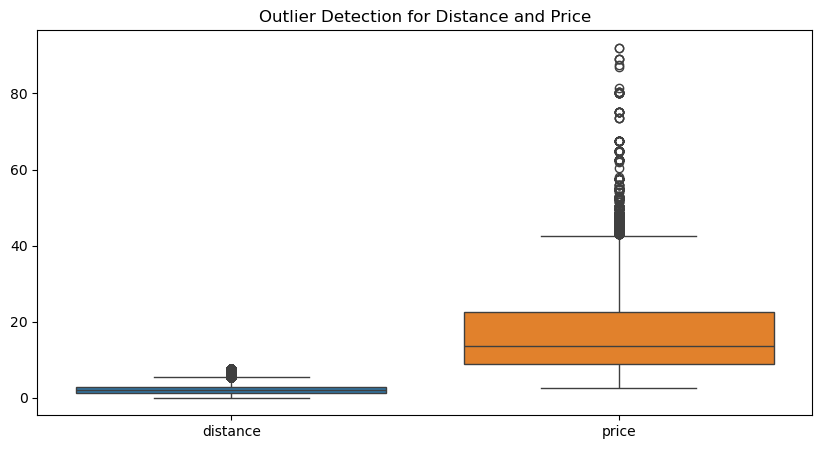

In [18]:
plt.figure(figsize=(10, 5))

sns.boxplot(data=data[['distance', 'price']])

plt.title('Outlier Detection for Distance and Price')
plt.show()

# Data Preparation

##  Remove Unnecessary Features

In [19]:
data.drop(['id', 'product_id'], axis=1, inplace=True)

data.head()

,distance,cab_type,time_stamp,destination,source,price,surge_multiplier,name
0,0.44,Lyft,1544952607890,North Station,Haymarket Square,5.0,1.0,Shared
1,0.44,Lyft,1543284023677,North Station,Haymarket Square,11.0,1.0,Lux
2,0.44,Lyft,1543366822198,North Station,Haymarket Square,7.0,1.0,Lyft
3,0.44,Lyft,1543553582749,North Station,Haymarket Square,26.0,1.0,Lux Black XL
4,0.44,Lyft,1543463360223,North Station,Haymarket Square,9.0,1.0,Lyft XL


## Handle Missing Values

In [20]:
shape_before = data.shape

data.dropna(subset=['price'], inplace=True)
data.reset_index(drop=True, inplace=True)

shape_after = data.shape

print("Shape Before:", shape_before)
print("Shape After:", shape_after)

Shape Before: (100000, 8)
Shape After: (92084, 8)


## Geospatial Processing

In [21]:
geolocator = Nominatim(
    user_agent="traffic_prediction_project",
    timeout=10
)

In [22]:
# Get unique locations
unique_locations = pd.concat([
    data['source'],
    data['destination']
]).dropna().unique()

# Store coordinates
location_coordinates = {}

# Geocode each location
for location in unique_locations:       
    result = geolocator.geocode(
        f"{location}, Boston, Massachusetts, USA"
    )

    if result:
        location_coordinates[location] = (
            result.latitude,
            result.longitude
        )

print("Number of Locations:", len(location_coordinates))

Number of Locations: 12


## Add Coordinates

In [23]:
data['source_latitude'] = data['source'].map(
    lambda x: location_coordinates[x][0]
)

data['source_longitude'] = data['source'].map(
    lambda x: location_coordinates[x][1]
)

data['destination_latitude'] = data['destination'].map(
    lambda x: location_coordinates[x][0]
)

data['destination_longitude'] = data['destination'].map(
    lambda x: location_coordinates[x][1]
)

data.head()

,distance,cab_type,time_stamp,destination,source,price,surge_multiplier,name,source_latitude,source_longitude,destination_latitude,destination_longitude
0,0.44,Lyft,1544952607890,North Station,Haymarket Square,5.0,1.0,Shared,42.36295,-71.057845,42.366299,-71.062162
1,0.44,Lyft,1543284023677,North Station,Haymarket Square,11.0,1.0,Lux,42.36295,-71.057845,42.366299,-71.062162
2,0.44,Lyft,1543366822198,North Station,Haymarket Square,7.0,1.0,Lyft,42.36295,-71.057845,42.366299,-71.062162
3,0.44,Lyft,1543553582749,North Station,Haymarket Square,26.0,1.0,Lux Black XL,42.36295,-71.057845,42.366299,-71.062162
4,0.44,Lyft,1543463360223,North Station,Haymarket Square,9.0,1.0,Lyft XL,42.36295,-71.057845,42.366299,-71.062162


## Temporal Features

In [24]:
# Extract time-based features and create a holiday indicator    

from pandas.tseries.holiday import USFederalHolidayCalendar

# Convert timestamp to datetime
data['time_stamp'] = pd.to_datetime(
    data['time_stamp'],
    unit='ms'
)

# Extract temporal features
data['year'] = data['time_stamp'].dt.year
data['month'] = data['time_stamp'].dt.month
data['day'] = data['time_stamp'].dt.day
data['day_of_week'] = data['time_stamp'].dt.day_of_week
data['hour'] = data['time_stamp'].dt.hour

# Rush hour indicator
data['is_rushhour'] = data['hour'].isin(
    [7, 8, 9, 16, 17, 18]
).astype(int)

# Weekend indicator
data['is_weekend'] = data['day_of_week'].isin(
    [5, 6]
).astype(int)

# Holiday indicator
holiday_calendar = USFederalHolidayCalendar()

holidays = holiday_calendar.holidays(
    start=data['time_stamp'].min(),
    end=data['time_stamp'].max()
)

data['is_holiday'] = (
    data['time_stamp'].dt.normalize().isin(holidays)
).astype(int)

data.head()

,distance,cab_type,time_stamp,destination,source,price,surge_multiplier,name,source_latitude,source_longitude,destination_latitude,destination_longitude,year,month,day,day_of_week,hour,is_rushhour,is_weekend,is_holiday
0,0.44,Lyft,2018-12-16 09:30:07.890,North Station,Haymarket Square,5.0,1.0,Shared,42.36295,-71.057845,42.366299,-71.062162,2018,12,16,6,9,1,1,0
1,0.44,Lyft,2018-11-27 02:00:23.677,North Station,Haymarket Square,11.0,1.0,Lux,42.36295,-71.057845,42.366299,-71.062162,2018,11,27,1,2,0,0,0
2,0.44,Lyft,2018-11-28 01:00:22.198,North Station,Haymarket Square,7.0,1.0,Lyft,42.36295,-71.057845,42.366299,-71.062162,2018,11,28,2,1,0,0,0
3,0.44,Lyft,2018-11-30 04:53:02.749,North Station,Haymarket Square,26.0,1.0,Lux Black XL,42.36295,-71.057845,42.366299,-71.062162,2018,11,30,4,4,0,0,0
4,0.44,Lyft,2018-11-29 03:49:20.223,North Station,Haymarket Square,9.0,1.0,Lyft XL,42.36295,-71.057845,42.366299,-71.062162,2018,11,29,3,3,0,0,0


### Remove Unnecessary Time Features

In [25]:
# Remove the original timestamp and year after extracting useful temporal features

data.drop(
    ['time_stamp', 'year'],
    axis=1,
    inplace=True
)

data.head()

,distance,cab_type,destination,source,price,surge_multiplier,name,source_latitude,source_longitude,destination_latitude,destination_longitude,month,day,day_of_week,hour,is_rushhour,is_weekend,is_holiday
0,0.44,Lyft,North Station,Haymarket Square,5.0,1.0,Shared,42.36295,-71.057845,42.366299,-71.062162,12,16,6,9,1,1,0
1,0.44,Lyft,North Station,Haymarket Square,11.0,1.0,Lux,42.36295,-71.057845,42.366299,-71.062162,11,27,1,2,0,0,0
2,0.44,Lyft,North Station,Haymarket Square,7.0,1.0,Lyft,42.36295,-71.057845,42.366299,-71.062162,11,28,2,1,0,0,0
3,0.44,Lyft,North Station,Haymarket Square,26.0,1.0,Lux Black XL,42.36295,-71.057845,42.366299,-71.062162,11,30,4,4,0,0,0
4,0.44,Lyft,North Station,Haymarket Square,9.0,1.0,Lyft XL,42.36295,-71.057845,42.366299,-71.062162,11,29,3,3,0,0,0


## Haversine Distance

In [26]:
def haversine(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(
        np.radians,
        [lat1, lon1, lat2, lon2]
    )

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2) ** 2
    )

    return 2 * 6371 * np.arcsin(np.sqrt(a))

In [27]:
data['distance_in_km'] = data.apply(
    lambda row: haversine(
        row['source_latitude'],
        row['source_longitude'],
        row['destination_latitude'],
        row['destination_longitude']
    ),
    axis=1
)

data.head()

,distance,cab_type,destination,source,price,surge_multiplier,name,source_latitude,source_longitude,destination_latitude,destination_longitude,month,day,day_of_week,hour,is_rushhour,is_weekend,is_holiday,distance_in_km
0,0.44,Lyft,North Station,Haymarket Square,5.0,1.0,Shared,42.36295,-71.057845,42.366299,-71.062162,12,16,6,9,1,1,0,0.51425
1,0.44,Lyft,North Station,Haymarket Square,11.0,1.0,Lux,42.36295,-71.057845,42.366299,-71.062162,11,27,1,2,0,0,0,0.51425
2,0.44,Lyft,North Station,Haymarket Square,7.0,1.0,Lyft,42.36295,-71.057845,42.366299,-71.062162,11,28,2,1,0,0,0,0.51425
3,0.44,Lyft,North Station,Haymarket Square,26.0,1.0,Lux Black XL,42.36295,-71.057845,42.366299,-71.062162,11,30,4,4,0,0,0,0.51425
4,0.44,Lyft,North Station,Haymarket Square,9.0,1.0,Lyft XL,42.36295,-71.057845,42.366299,-71.062162,11,29,3,3,0,0,0,0.51425


## Train - Validation - Test Split


In [28]:
X = data.drop (['price', 'surge_multiplier'],axis=1 )
y = data['price']

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=42
)


In [29]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.17647,
    random_state=42
)

In [30]:
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (64458, 17)
X_val: (13813, 17)
X_test: (13813, 17)


## Remove Outliers

### Remove Outliers

In [75]:
# Calculate outlier limits using the training data only.
# The test set is kept unchanged for a fair evaluation.

outlier_columns = ['distance']

for column in outlier_columns:
    Q1 = X_train[column].quantile(0.25)
    Q3 = X_train[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    mask = X_train[column].between(
        lower_bound,
        upper_bound
    )

    X_train = X_train[mask]
    y_train = y_train[mask]


# Remove price outliers from the training target only.

Q1 = y_train.quantile(0.25)
Q3 = y_train.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

mask = y_train.between(
    lower_bound,
    upper_bound
)

X_train = X_train[mask]
y_train = y_train[mask]


print("Training Shape After Outlier Removal:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape After Outlier Removal: (63164, 29)
Testing Shape: (13813, 29)


### Outlier Detection After Removal


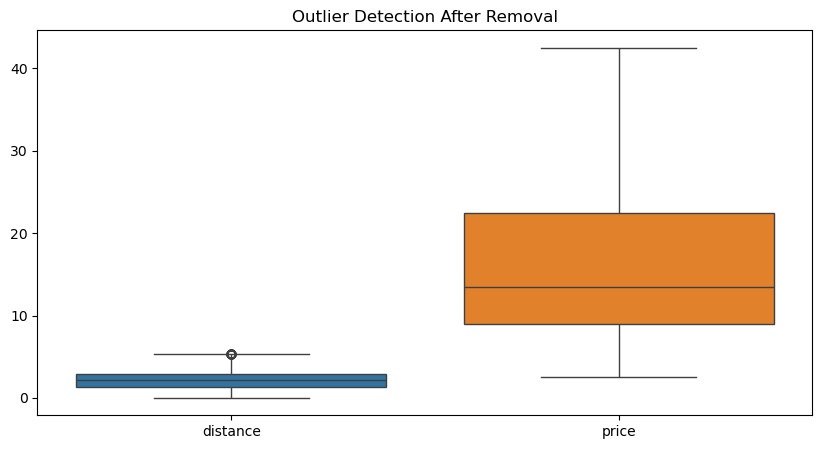

In [76]:
# Check the training data again after removing outliers.

plt.figure(figsize=(10, 5))

sns.boxplot(
    data=pd.DataFrame({
        'distance': X_train['distance'],
        'price': y_train
    })
)

plt.title('Outlier Detection After Removal')
plt.show()

## Encoding

### One-Hot Encoding


In [33]:
encoder = OneHotEncoder(
    sparse_output=False,
    handle_unknown='ignore'
)

categorical_columns = ['cab_type', 'name']

encoded_train = encoder.fit_transform(
    X_train[categorical_columns]
)

encoded_val = encoder.transform(
    X_val[categorical_columns]
)

encoded_test = encoder.transform(
    X_test[categorical_columns]
)

#### What We Did

We used One-Hot Encoding to convert the categorical features
`cab_type` and `name` into numerical columns.

The encoder was fitted on the training data only, then applied
to the validation and test data to prevent data leakage.

### Target Encoding

In [34]:
source_encoder = TargetEncoder(smooth='auto')
destination_encoder = TargetEncoder(smooth='auto')

# Encode source
X_train['source_encoded'] = source_encoder.fit_transform(
    X_train[['source']],
    y_train
)

X_val['source_encoded'] = source_encoder.transform(
    X_val[['source']]
)

X_test['source_encoded'] = source_encoder.transform(
    X_test[['source']]
)

# Encode destination
X_train['destination_encoded'] = destination_encoder.fit_transform(
    X_train[['destination']],
    y_train
)

X_val['destination_encoded'] = destination_encoder.transform(
    X_val[['destination']]
)

X_test['destination_encoded'] = destination_encoder.transform(
    X_test[['destination']]
)

#### What We Did

We used Target Encoding for `source` and `destination`
because they contain location categories with relatively high cardinality.

Each location was converted into a numerical value based on
its relationship with the target variable `price`.

The encoders were fitted using the training data and training target only,
then applied to the validation and test data.

### Finalize Encoding

In [35]:
# Remove the original categorical columns and add the encoded features.

original_categorical_columns = [
    'cab_type',
    'name',
    'source',
    'destination'
]

X_train.drop(
    original_categorical_columns,
    axis=1,
    inplace=True
)

X_val.drop(
    original_categorical_columns,
    axis=1,
    inplace=True
)

X_test.drop(
    original_categorical_columns,
    axis=1,
    inplace=True
)

# Create DataFrames for the One-Hot encoded features.

encoded_train_df = pd.DataFrame(
    encoded_train,
    columns=encoder.get_feature_names_out(categorical_columns),
    index=X_train.index
)

encoded_val_df = pd.DataFrame(
    encoded_val,
    columns=encoder.get_feature_names_out(categorical_columns),
    index=X_val.index
)

encoded_test_df = pd.DataFrame(
    encoded_test,
    columns=encoder.get_feature_names_out(categorical_columns),
    index=X_test.index
)

# Add the encoded features.

X_train = pd.concat(
    [X_train, encoded_train_df],
    axis=1
)

X_val = pd.concat(
    [X_val, encoded_val_df],
    axis=1
)

X_test = pd.concat(
    [X_test, encoded_test_df],
    axis=1
)

print("X_train Shape:", X_train.shape)
print("X_val Shape:", X_val.shape)
print("X_test Shape:", X_test.shape)

X_train Shape: (63330, 29)
X_val Shape: (13813, 29)
X_test Shape: (13813, 29)


#### What We Did

We removed the original categorical columns after encoding
and combined the encoded features with the remaining numerical features.

This produced the final numerical feature sets for the training,
validation, and test datasets.

## Scaling

In [36]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

X_test_scaled = scaler.transform(X_test)

In [37]:
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_val_scaled = pd.DataFrame(
    X_val_scaled,
    columns=X_val.columns,
    index=X_val.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

In [38]:
print("X_train_scaled Shape:", X_train_scaled.shape)
print("X_val_scaled Shape:", X_val_scaled.shape)
print("X_test_scaled Shape:", X_test_scaled.shape)

X_train_scaled Shape: (63330, 29)
X_val_scaled Shape: (13813, 29)
X_test_scaled Shape: (13813, 29)


In [39]:
# Check scaled values
X_train_scaled.head()

,distance,source_latitude,source_longitude,destination_latitude,destination_longitude,month,day,day_of_week,hour,is_rushhour,...,name_Lux,name_Lux Black,name_Lux Black XL,name_Lyft,name_Lyft XL,name_Shared,name_UberPool,name_UberX,name_UberXL,name_WAV
48194,-0.830345,-0.308555,0.507671,0.874201,0.486539,0.860026,-0.498089,0.115275,0.349147,-0.564525,...,-0.297458,-0.297395,-0.291314,3.354030,-0.299403,-0.300247,-0.309375,-0.304602,-0.305158,-0.305869
14149,0.680951,0.976345,0.410207,-0.515838,-0.112550,-1.162756,1.202292,0.603431,0.062944,-0.564525,...,-0.297458,-0.297395,-0.291314,-0.298149,-0.299403,-0.300247,-0.309375,-0.304602,3.276987,-0.305869
71754,-1.524210,0.868230,0.488788,1.245700,0.429541,-1.162756,1.002247,-0.372881,0.778452,1.771402,...,-0.297458,-0.297395,3.432726,-0.298149,-0.299403,-0.300247,-0.309375,-0.304602,-0.305158,-0.305869
54666,0.557386,-1.114931,-0.118023,0.476628,-3.209195,0.860026,-0.498089,0.115275,0.206045,-0.564525,...,-0.297458,-0.297395,3.432726,-0.298149,-0.299403,-0.300247,-0.309375,-0.304602,-0.305158,-0.305869
41587,-0.022420,-0.530513,-0.100190,-0.484195,0.197622,0.860026,-0.498089,0.115275,1.637061,-0.564525,...,-0.297458,3.362536,-0.291314,-0.298149,-0.299403,-0.300247,-0.309375,-0.304602,-0.305158,-0.305869


#### What We Did

We used StandardScaler to put the numerical features on a similar scale.

The scaler was fitted using the training data only, then applied to the validation and test data.

This helps prevent features with larger numerical ranges from dominating the model and prepares the data for algorithms such as KMeans and PCA.

# Exploratory Data Analysis (EDA)

## Geographic Analysis

In [ ]:
# Check Coordinatesy

data[
    [
        'source',
        'source_latitude',
        'source_longitude',
        'destination',
        'destination_latitude',
        'destination_longitude'
    ]
].head()

,source,source_latitude,source_longitude,destination,destination_latitude,destination_longitude
0,Haymarket Square,42.36295,-71.057845,North Station,42.366299,-71.062162
1,Haymarket Square,42.36295,-71.057845,North Station,42.366299,-71.062162
2,Haymarket Square,42.36295,-71.057845,North Station,42.366299,-71.062162
3,Haymarket Square,42.36295,-71.057845,North Station,42.366299,-71.062162
4,Haymarket Square,42.36295,-71.057845,North Station,42.366299,-71.062162


In [41]:
# Geographic Heat Map
# Visualize ride density and pricing variations by pickup location

location_count = (
    data.groupby(
        ['source', 'source_latitude', 'source_longitude']
    )
    .size()
    .reset_index(name='Ride_density')
)

location_price = (
    data.groupby(
        ['source', 'source_latitude', 'source_longitude']
    )['price']
    .mean()
    .reset_index(name='price')
)

map_data = location_count.merge(
    location_price,
    on=['source', 'source_latitude', 'source_longitude']
)

fig = px.scatter_map(
    map_data,
    lat='source_latitude',
    lon='source_longitude',
    color='Ride_density',
    size='price',
    hover_name='source',
    hover_data={
        'Ride_density': True,
        'price': ':.2f',
        'source_latitude': False,
        'source_longitude': False
    },
    map_style='carto-positron',
    center={
        'lat': 42.36,
        'lon': -71.06
    },
    zoom=11,
    title='Geographic Data Plot'
)

fig.show()

#### What We Did

We created an interactive geographic map of the pickup locations

Ride density is represented by the color of each location,
while the average ride price is represented by the point size

This helps us identify areas with higher ride demand
and compare pricing variations across Boston

## Temporal Analysis


### Temporal Analysis - hours of the day

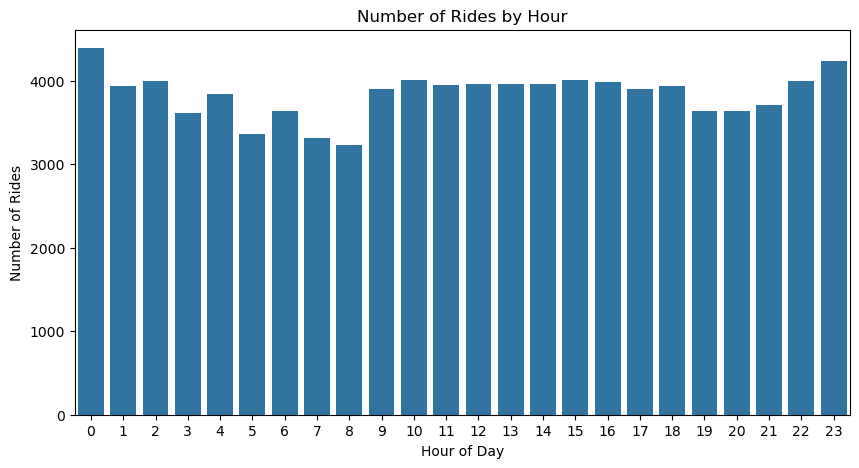

In [42]:
# Analyze ride patterns across different hours of the day.

plt.figure(figsize=(10, 5))

sns.countplot(
    x=data['hour'],
    order=sorted(data['hour'].unique())
)

plt.title('Number of Rides by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Rides')

plt.show()

#### What We Did

We analyzed the number of rides across different hours of the day
to identify peak and low-demand periods

### Temporal Analysis - Day of Week

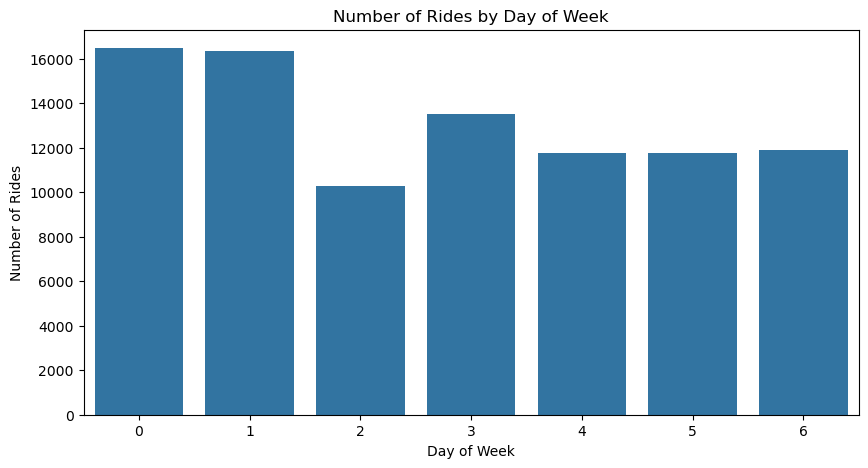

In [43]:
# Analyze the number of rides across different days of the week.

plt.figure(figsize=(10, 5))

sns.countplot(
    x=data['day_of_week'],
    order=sorted(data['day_of_week'].unique())
)

plt.title('Number of Rides by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Rides')

plt.show()

#### What We Did

We analyzed the number of rides across different days of the week
to identify differences in ride activity between weekdays and weekends

### Temporal Analysis - Month

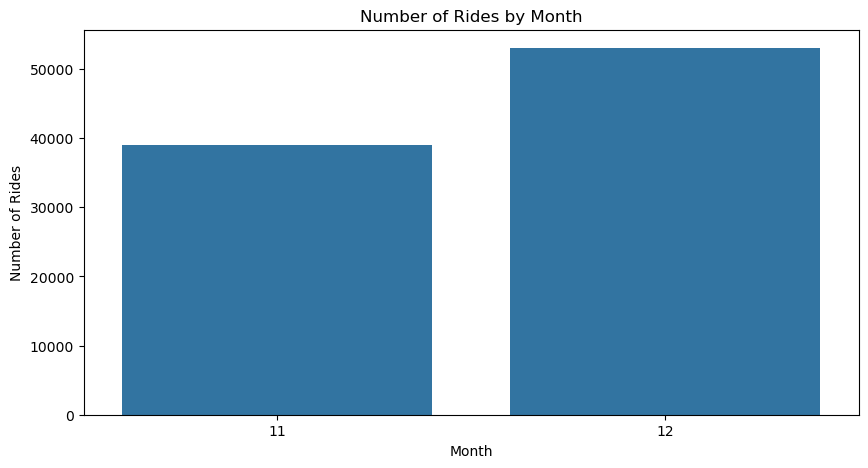

In [44]:
# Analyze the number of rides across different months.

plt.figure(figsize=(10, 5))

sns.countplot(
    x=data['month'],
    order=sorted(data['month'].unique())
)

plt.title('Number of Rides by Month')
plt.xlabel('Month')
plt.ylabel('Number of Rides')

plt.show()

#### What We Did

We analyzed the number of rides across different months
to identify seasonal differences in ride activity

## Service Comparison

### Uber vs Lyft

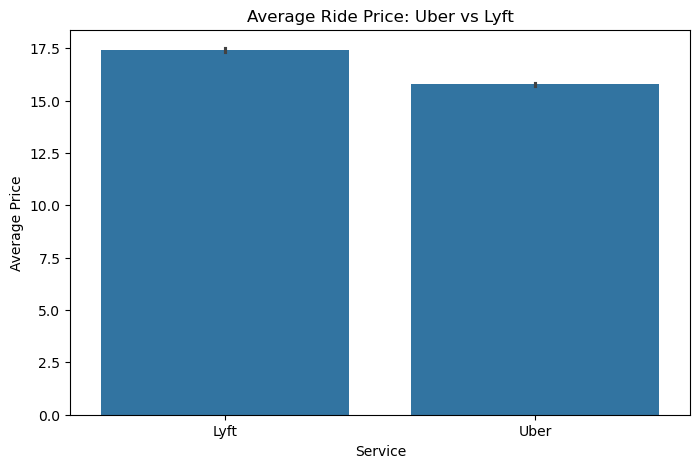

In [45]:
# Compare the average ride price between Uber and Lyft.

plt.figure(figsize=(8, 5))

sns.barplot(
    data=data,
    x='cab_type',
    y='price'
)

plt.title('Average Ride Price: Uber vs Lyft')
plt.xlabel('Service')
plt.ylabel('Average Price')

plt.show()

#### What We Did

We compared the average ride prices between Uber and Lyft.

The analysis shows that Lyft has a slightly higher average
ride price than Uber in our dataset

### Availability

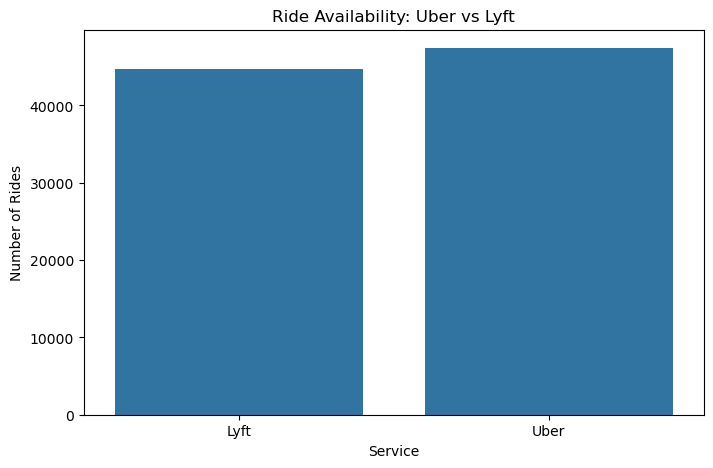

In [46]:
# Compare the number of available ride records for Uber and Lyft.

plt.figure(figsize=(8, 5))

sns.countplot(
    data=data,
    x='cab_type'
)

plt.title('Ride Availability: Uber vs Lyft')
plt.xlabel('Service')
plt.ylabel('Number of Rides')

plt.show()

#### What We Did

We compared the number of recorded rides for Uber and Lyft

Uber has slightly more ride records than Lyft in our dataset
Since there is no direct availability feature, this comparison
represents recorded ride volume rather than actual real-world availability

## Surge Pricing Analysis

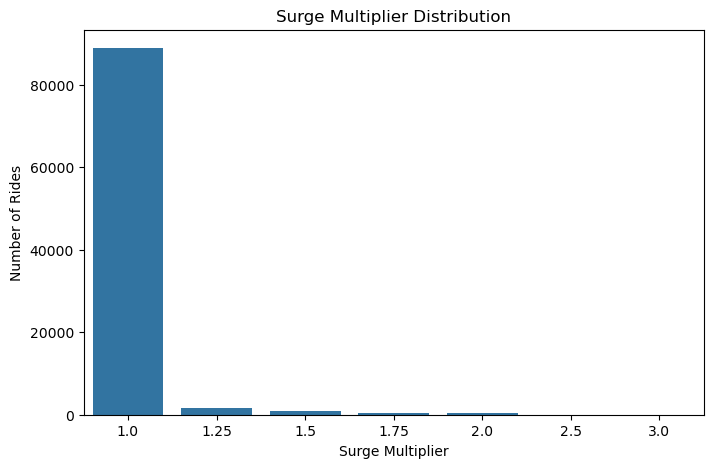

In [47]:
# Analyze the distribution of surge multiplier values.

plt.figure(figsize=(8, 5))

sns.countplot(
    data=data,
    x='surge_multiplier'
)

plt.title('Surge Multiplier Distribution')
plt.xlabel('Surge Multiplier')
plt.ylabel('Number of Rides')

plt.show()

#### What We Did

We analyzed the distribution of surge multiplier values
to understand how frequently different surge levels occur
in the dataset

###  Surge Analysis by Hour


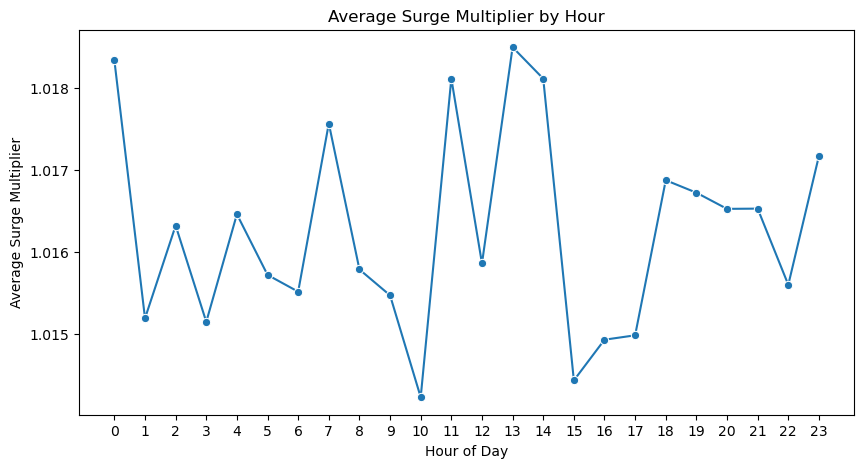

In [48]:
# Analyze the average surge multiplier across different hours of the day

surge_by_hour = (
    data.groupby('hour')['surge_multiplier']
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=surge_by_hour,
    x='hour',
    y='surge_multiplier',
    marker='o'
)

plt.title('Average Surge Multiplier by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average Surge Multiplier')

plt.xticks(range(24))

plt.show()

#### What We Did

We analyzed the average surge multiplier across different hours of the day.

The results show that the surge multiplier remains relatively stable,
with only small variations between different hours

###  Surge Analysis by Service

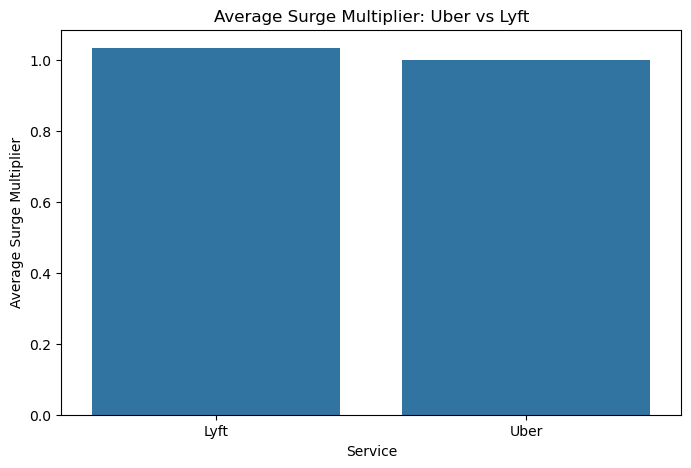

In [49]:
# Compare the average surge multiplier between Uber and Lyft.

surge_by_service = (
    data.groupby('cab_type')['surge_multiplier']
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=surge_by_service,
    x='cab_type',
    y='surge_multiplier'
)

plt.title('Average Surge Multiplier: Uber vs Lyft')
plt.xlabel('Service')
plt.ylabel('Average Surge Multiplier')

plt.show()

#### What We Did

We compared the average surge multiplier between Uber and Lyft.

The results show that the two services have very similar average
surge levels, with Lyft being slightly higher than Uber.

##  Route Popularity & Congestion Correlation Analysis

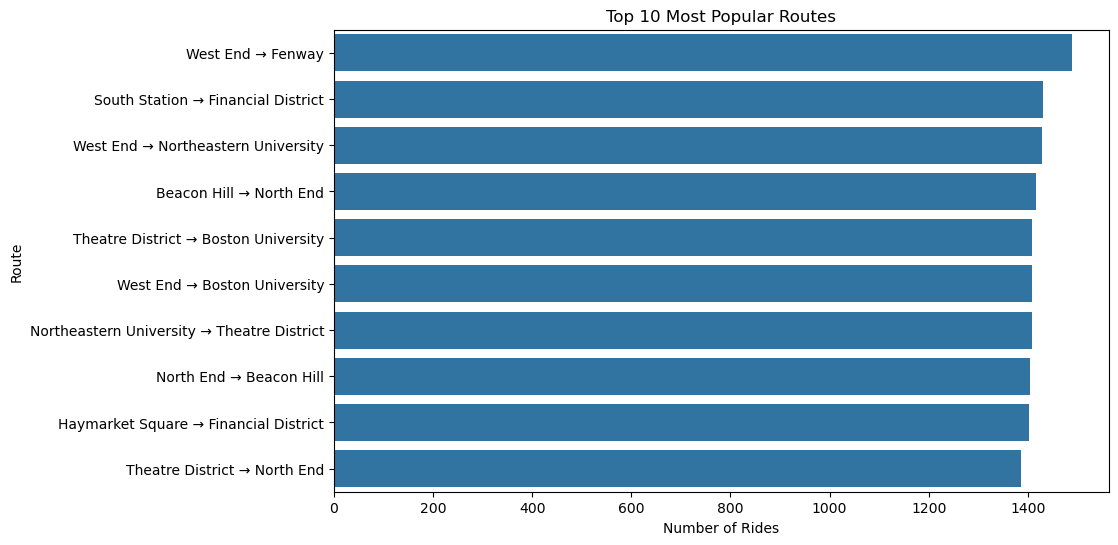

In [50]:
# Identify the most frequently used source-destination routes

route_counts = (
    data.groupby(['source', 'destination'])
    .size()
    .reset_index(name='ride_count')
    .sort_values('ride_count', ascending=False)
)

top_routes = route_counts.head(10).copy()

top_routes['route'] = (
    top_routes['source'] + ' → ' + top_routes['destination']
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_routes,
    y='route',
    x='ride_count'
)

plt.title('Top 10 Most Popular Routes')
plt.xlabel('Number of Rides')
plt.ylabel('Route')

plt.show()

#### What We Did

We identified the top 10 most popular routes based on the number of rides

The results show that ride demand is concentrated on specific
source-destination pairs, with West End → Fenway being the most popular route

### Route Popularity & Congestion Correlation

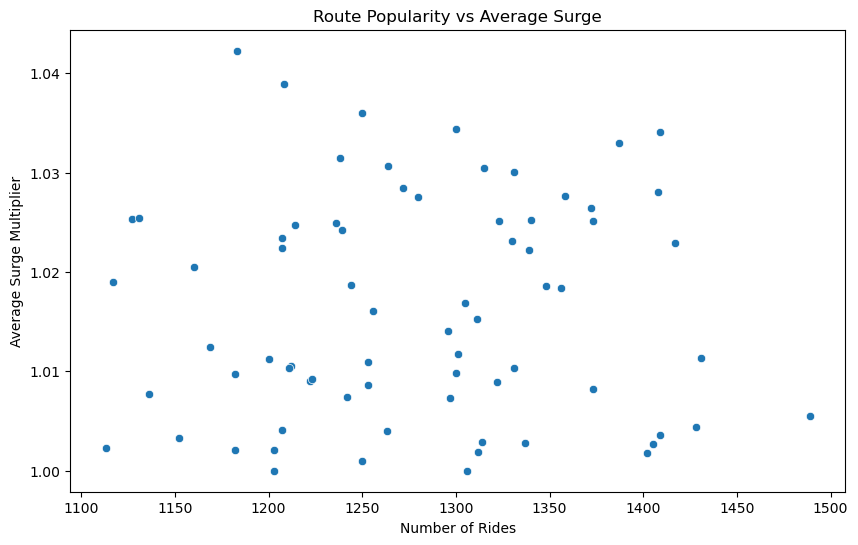

In [51]:
# Compare route popularity with the average surge multiplier
# Surge multiplier is used as an indirect indicator of demand pressure

route_analysis = (
    data.groupby(['source', 'destination'])
    .agg(
        ride_count=('price', 'size'),
        average_surge=('surge_multiplier', 'mean')
    )
    .reset_index()
)

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=route_analysis,
    x='ride_count',
    y='average_surge'
)

plt.title('Route Popularity vs Average Surge')
plt.xlabel('Number of Rides')
plt.ylabel('Average Surge Multiplier')

plt.show()

#### What We Did

We analyzed the relationship between route popularity and the average surge multiplier for each source-destination route.

For each route, we calculated the total number of recorded rides and the average surge multiplier.

We then used a scatter plot to examine whether more popular routes tend to have higher surge levels.

Since the dataset does not contain a direct congestion feature, the average surge multiplier was used as an indirect indicator of demand pressure.

### Correlation Analysis

In [52]:
# Measure the relationship between route popularity and average surge

correlation = route_analysis[
    ['ride_count', 'average_surge']
].corr().iloc[0, 1]

print("Correlation between Route Popularity and Average Surge:", round(correlation, 3))

Correlation between Route Popularity and Average Surge: 0.021


#### What We Did

We calculated the correlation between route popularity and average surge.

The correlation value of -0.035 indicates a very weak relationship,
which suggests that route popularity does not strongly explain surge levels
in our dataset.

### Correlation Heatmap

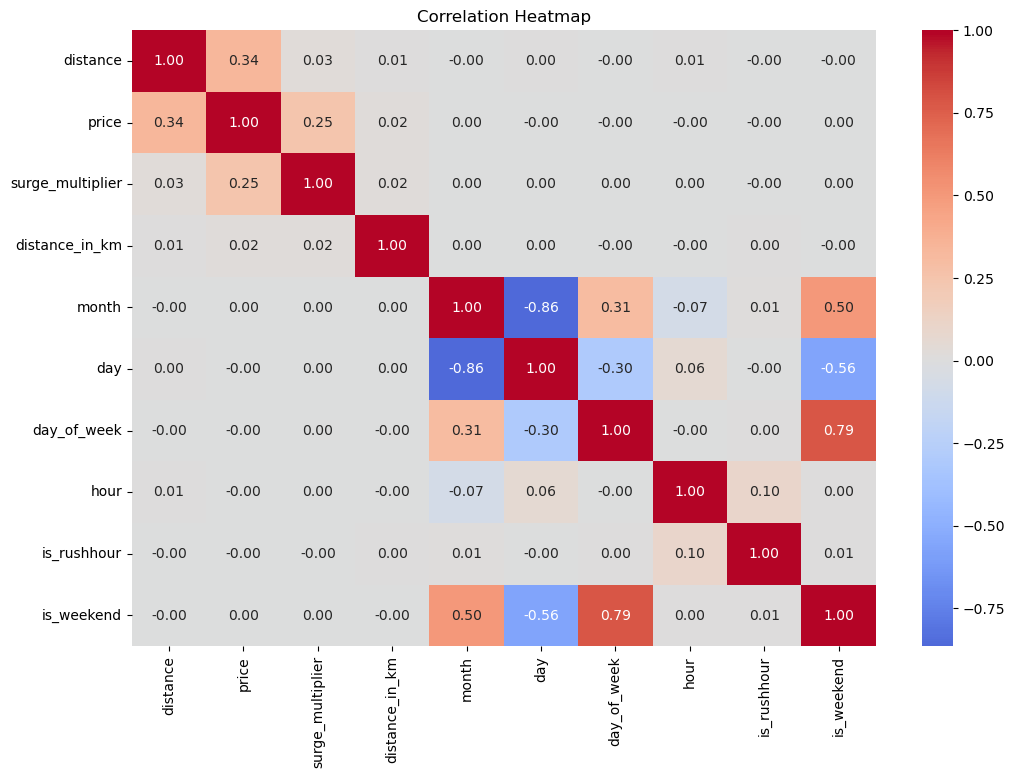

In [53]:
# Visualize correlations between the main numerical features and the target

correlation_data = data[
    [
        'distance',
        'price',
        'surge_multiplier',
        'distance_in_km',
        'month',
        'day',
        'day_of_week',
        'hour',
        'is_rushhour',
        'is_weekend'
    ]
]

correlation_matrix = correlation_data.corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Heatmap')
plt.show()

#### What We Did

We created a correlation heatmap to examine the relationships between
the main numerical features and the target variable, price

This helps identify which numerical features have stronger or weaker
linear relationships with ride price before building the predictive models

# Supervised Learning

## Baseline Model

In [54]:
baseline_value = y_train.mean()

print("Baseline Predicted Price (Mean of y_train):", baseline_value)

y_pred_baseline = np.full(
    shape=y_val.shape,
    fill_value=baseline_value
)

# Evaluate the baseline
baseline_mae = mean_absolute_error(
    y_val,
    y_pred_baseline
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        y_pred_baseline
    )
)

baseline_r2 = r2_score(
    y_val,
    y_pred_baseline
)

Baseline Predicted Price (Mean of y_train): 16.239894204958155


In [55]:
print("Baseline MAE :", baseline_mae)
print("Baseline RMSE:", baseline_rmse)
print("Baseline R²  :", baseline_r2)

Baseline MAE : 7.529047441892324
Baseline RMSE: 9.36534188471982
Baseline R²  : -0.0010380846209998573


#### What We Did

We built a Mean Baseline that predicts the average ride price
from the training data for every validation sample.

We evaluated the baseline using MAE, RMSE, and R².

The baseline provides a reference point for comparing the
performance of the machine learning models that will be built next.

## XGBoost Regressor

In [56]:
# XGBoost Model

xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train_scaled,
    y_train
)

y_val_pred_xgb = xgb_model.predict(
    X_val_scaled
)

xgb_mae = mean_absolute_error(
    y_val,
    y_val_pred_xgb
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        y_val_pred_xgb
    )
)

xgb_r2 = r2_score(
    y_val,
    y_val_pred_xgb
)


In [57]:
print("XGBoost MAE:", xgb_mae)
print("XGBoost RMSE:", xgb_rmse)
print("XGBoost R²:", xgb_r2)

XGBoost MAE: 1.3834099171517735
XGBoost RMSE: 2.599986311839888
XGBoost R²: 0.9228483086001907


#### What We Did

We trained an XGBoost Regressor to predict ride prices
using the prepared training features.

The model was trained on the training data and evaluated
on the validation data using MAE, RMSE, and R².

The results provide a basis for comparing XGBoost with the
baseline and other machine learning models.

## Random Forest Regressor

In [58]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_scaled,
    y_train
)

y_val_pred_rf = rf_model.predict(
    X_val_scaled
)

mae_rf = mean_absolute_error(
    y_val,
    y_val_pred_rf
)

rmse_rf = np.sqrt(
    mean_squared_error(
        y_val,
        y_val_pred_rf
    )
)

r2_rf = r2_score(
    y_val,
    y_val_pred_rf
)



In [59]:
print("Random Forest MAE:", mae_rf)
print("Random Forest RMSE:", rmse_rf)
print("Random Forest R²:", r2_rf)

Random Forest MAE: 1.4484136790566513
Random Forest RMSE: 2.679908373184899
Random Forest R²: 0.9180322111592719


#### What We Did

We trained a Random Forest Regressor to predict ride prices
using the prepared training features.

The model was trained on the training data and evaluated
on the validation data using MAE, RMSE, and R².

These metrics will be used to compare Random Forest
with the Baseline and XGBoost models.

### Feature Importance

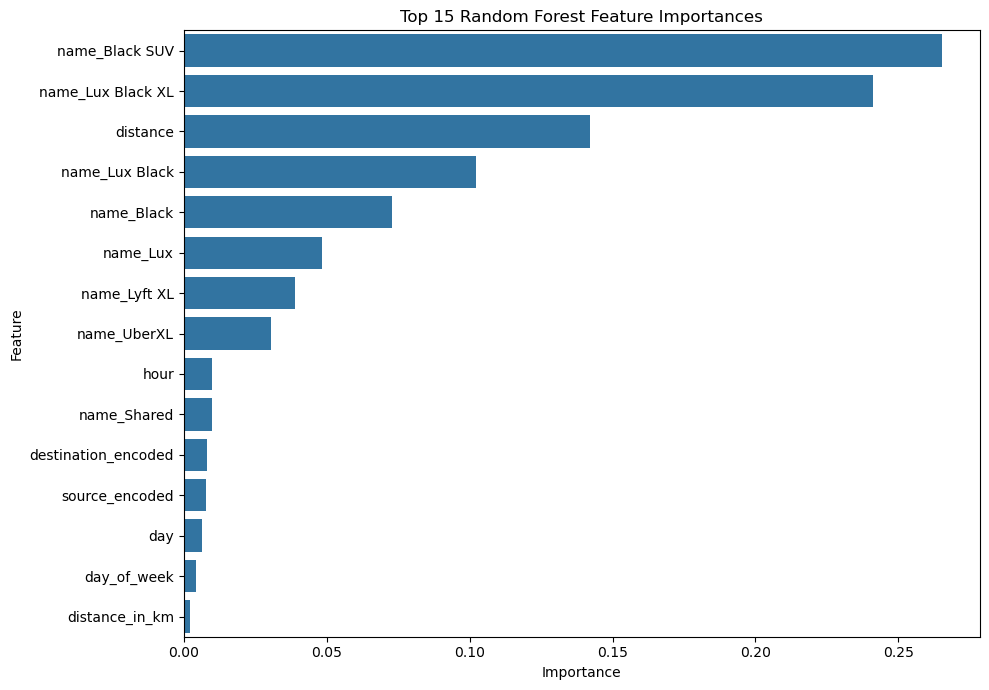

In [60]:
feature_importance = pd.DataFrame({
    "Feature": X_train_scaled.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

#### What We Did

We analyzed the Feature Importance values from the Random Forest model
to identify which features contributed most to predicting ride prices.

We ranked the features by their importance and visualized
the top 15 features using a horizontal bar chart.

This helps us understand which factors have the greatest influence
on the model's price predictions.

## Model Comparison

In [61]:
model_comparison = pd.DataFrame({
    'Model': [
        'Baseline',
        'XGBoost',
        'Random Forest'
    ],
    'MAE': [
        baseline_mae,
        xgb_mae,
        mae_rf
    ],
    'RMSE': [
        baseline_rmse,
        xgb_rmse,
        rmse_rf
    ],
    'R²': [
        baseline_r2,
        xgb_r2,
        r2_rf
    ]
})

model_comparison

,Model,MAE,RMSE,R²
0,Baseline,7.529047,9.365342,-0.001038
1,XGBoost,1.383410,2.599986,0.922848
2,Random Forest,1.448414,2.679908,0.918032


#### What We Did

We compared the performance of the Baseline, XGBoost, and Random Forest
models using MAE, RMSE, and R² on the validation data.

Lower MAE and RMSE indicate better prediction accuracy,
while a higher R² indicates better model performance.

This comparison helps us identify the best-performing model
before performing the final evaluation on the test data.

## Final Model Evaluation

In [62]:
y_test_pred_xgb = xgb_model.predict(
    X_test_scaled
)

test_mae = mean_absolute_error(
    y_test,
    y_test_pred_xgb
)

test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_test_pred_xgb
    )
)

test_r2 = r2_score(
    y_test,
    y_test_pred_xgb
)

In [63]:

print("Final XGBoost Test MAE:", test_mae)
print("Final XGBoost Test RMSE:", test_rmse)
print("Final XGBoost Test R²:", test_r2)

Final XGBoost Test MAE: 1.3934407590620161
Final XGBoost Test RMSE: 2.6045764992390126
Final XGBoost Test R²: 0.9217395536343862


#### What We Did

We evaluated the selected XGBoost model on the unseen test data
using MAE, RMSE, and R².

The final test results were very close to the validation results,
showing that the model maintained consistent performance on unseen data.

This provides the final performance evaluation of the selected model
for ride price prediction.

# Unsupervised Learning

## KMeans

### Feature Selection for KMeans

In [64]:
cluster_features = [
    'distance_in_km',
    'hour',
    'day_of_week',
    'is_rushhour',
    'source_latitude',
    'source_longitude',
    'destination_latitude',
    'destination_longitude'
]

clustering_data = data[
    cluster_features
    + [
        'source',
        'destination',
        'price',
        'surge_multiplier'
    ]
].dropna().copy()

print(
    "Clustering Data Shape:",
    clustering_data.shape
)

clustering_data.head()

Clustering Data Shape: (92084, 12)


,distance_in_km,hour,day_of_week,is_rushhour,source_latitude,source_longitude,destination_latitude,destination_longitude,source,destination,price,surge_multiplier
0,0.51425,9,6,1,42.36295,-71.057845,42.366299,-71.062162,Haymarket Square,North Station,5.0,1.0
1,0.51425,2,1,0,42.36295,-71.057845,42.366299,-71.062162,Haymarket Square,North Station,11.0,1.0
2,0.51425,1,2,0,42.36295,-71.057845,42.366299,-71.062162,Haymarket Square,North Station,7.0,1.0
3,0.51425,4,4,0,42.36295,-71.057845,42.366299,-71.062162,Haymarket Square,North Station,26.0,1.0
4,0.51425,3,3,0,42.36295,-71.057845,42.366299,-71.062162,Haymarket Square,North Station,9.0,1.0


#### What We Did

We selected the features that describe the mobility characteristics
of each ride, including distance, time, rush-hour status, and geographic location.

The original source and destination labels were kept for building
Mobility Profiles after clustering.

Price and surge multiplier were kept for later cluster analysis,
but they were not used as inputs for the KMeans algorithm.

### Scaling for KMeans

In [65]:
cluster_scaler = StandardScaler()

X_cluster_scaled = cluster_scaler.fit_transform(
    clustering_data[cluster_features]
)

X_cluster_scaled = pd.DataFrame(
    X_cluster_scaled,
    columns=cluster_features,
    index=clustering_data.index
)

X_cluster_scaled.head()

,distance_in_km,hour,day_of_week,is_rushhour,source_latitude,source_longitude,destination_latitude,destination_longitude
0,-0.694361,-0.366635,1.581299,1.770352,0.877079,0.487927,1.258654,0.432654
1,-0.694361,-1.368458,-0.863961,-0.564859,0.877079,0.487927,1.258654,0.432654
2,-0.694361,-1.511576,-0.374909,-0.564859,0.877079,0.487927,1.258654,0.432654
3,-0.694361,-1.082223,0.603195,-0.564859,0.877079,0.487927,1.258654,0.432654
4,-0.694361,-1.225341,0.114143,-0.564859,0.877079,0.487927,1.258654,0.432654


#### What We Did

We scaled the selected mobility features using StandardScaler
so that features with different numerical ranges have a comparable effect
on the distance calculations used by KMeans.

The scaler was fitted only on the clustering features and is separate
from the scaler used for price prediction.

### K Selection Check

In [66]:
inertia_values = []
silhouette_values = []

k_range = range(2, 15)

sample = X_cluster_scaled.sample(
    n=min(20000, len(X_cluster_scaled)),
    random_state=42
)

for k in k_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(sample)

    inertia_values.append(
        kmeans.inertia_
    )

    silhouette_values.append(
        silhouette_score(
            sample,
            labels
        )
    )

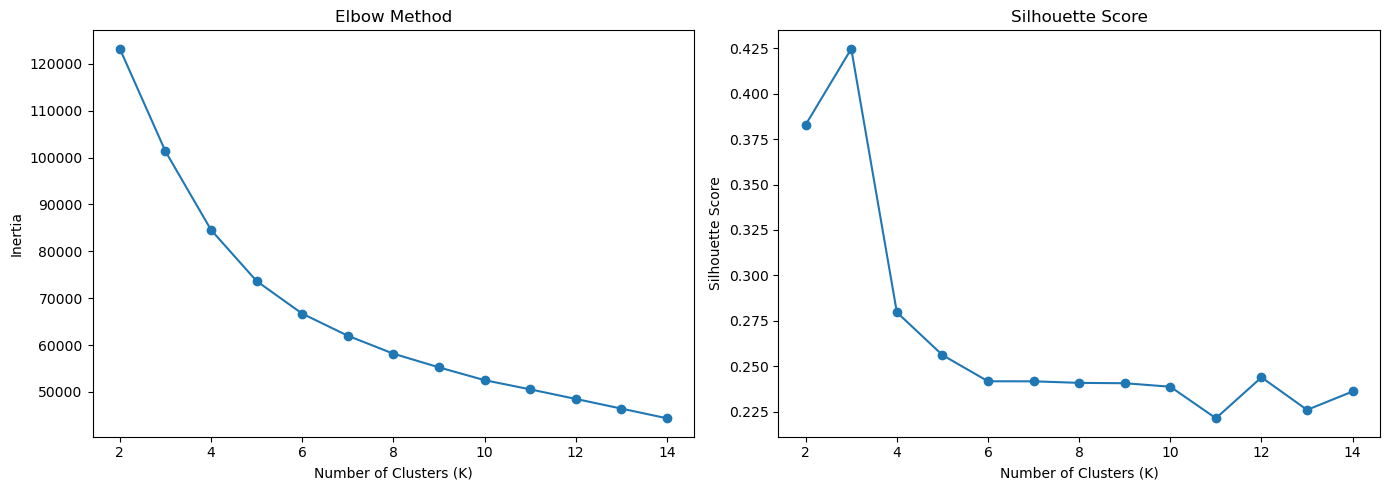

In [67]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

axes[0].plot(
    list(k_range),
    inertia_values,
    marker='o'
)

axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Inertia")

axes[1].plot(
    list(k_range),
    silhouette_values,
    marker='o'
)

axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

#### What We Did

We evaluated different values of K using the Elbow Method
and Silhouette Score as a sanity check.

The final clustering was performed using K = 10
to create a richer set of mobility profiles.

### KMeans Clustering

In [68]:
kmeans_model = KMeans(
    n_clusters=10,
    random_state=42,
    n_init=10
)

clustering_data['cluster'] = kmeans_model.fit_predict(
    X_cluster_scaled
)

data.loc[
    clustering_data.index,
    'cluster'
] = clustering_data['cluster']

clustering_data[
    [
        'distance_in_km',
        'hour',
        'source',
        'destination',
        'cluster'
    ]
].head()

,distance_in_km,hour,source,destination,cluster
0,0.51425,9,Haymarket Square,North Station,0
1,0.51425,2,Haymarket Square,North Station,6
2,0.51425,1,Haymarket Square,North Station,7
3,0.51425,4,Haymarket Square,North Station,7
4,0.51425,3,Haymarket Square,North Station,7


In [69]:
print(
    "Number of Clusters:",
    clustering_data['cluster'].nunique()
)

print(
    "Cluster Labels:",
    sorted(
        clustering_data['cluster'].unique()
    )
)

Number of Clusters: 10
Cluster Labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


#### What We Did

We applied KMeans with 10 clusters to the scaled mobility features.

Each ride was assigned a cluster label from 0 to 9 based on
its similarity to other rides.

The cluster labels were also added to the main dataset for
further mobility analysis and profile creation.

### Cluster Sizes

In [70]:
cluster_sizes = (
    clustering_data['cluster']
    .value_counts()
    .sort_index()
)

print("Number of Rides per Cluster:")
print(cluster_sizes)

Number of Rides per Cluster:
cluster
0     9117
1     9314
2     8080
3     7754
4     9152
5    11996
6     9192
7    10068
8     9293
9     8118
Name: count, dtype: int64


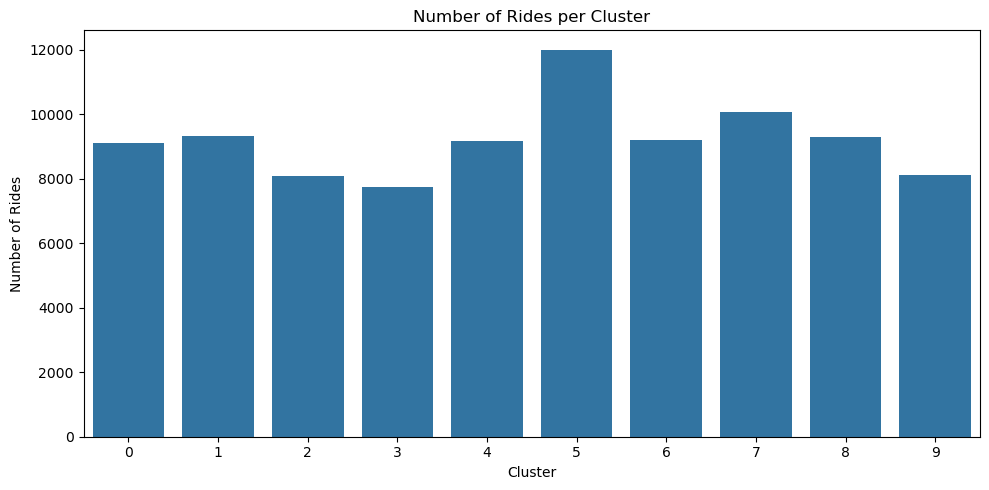

In [71]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=cluster_sizes.index.astype(str),
    y=cluster_sizes.values
)

plt.title("Number of Rides per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Rides")
plt.tight_layout()
plt.show()

## Mobility Profiles

In [72]:
def most_common(series):
    return series.mode().iloc[0]


mobility_profiles = (
    clustering_data
    .groupby('cluster')
    .agg(
        average_distance_km=(
            'distance_in_km',
            'mean'
        ),
        average_price=(
            'price',
            'mean'
        ),
        average_surge=(
            'surge_multiplier',
            'mean'
        ),
        most_common_hour=(
            'hour',
            most_common
        ),
        most_common_source=(
            'source',
            most_common
        ),
        most_common_destination=(
            'destination',
            most_common
        ),
        number_of_rides=(
            'cluster',
            'count'
        )
    )
    .round(2)
)

mobility_profiles

,average_distance_km,average_price,average_surge,most_common_hour,most_common_source,most_common_destination,number_of_rides
cluster,,,,,,,
0,2.37,16.48,1.01,18,West End,Northeastern University,9117
1,2.48,16.83,1.01,23,West End,Fenway,9314
2,21.45,16.56,1.02,23,Theatre District,Boston University,8080
3,21.45,16.02,1.02,0,Northeastern University,Theatre District,7754
4,3.10,17.76,1.01,0,West End,Northeastern University,9152
5,2.75,17.72,1.02,22,Northeastern University,North Station,11996
6,1.18,14.14,1.01,15,North End,North End,9192
7,1.76,15.61,1.01,1,Haymarket Square,Haymarket Square,10068
8,2.30,16.78,1.02,16,Northeastern University,North Station,9293


#### What We Did

We summarized each cluster using key mobility characteristics,
including average distance, average price, average surge,
most common ride hour, most common source, most common destination,
and number of rides.

These statistics help us interpret each cluster and turn it into
a human-readable Mobility Profile.

### Mobility Profiles Visualization

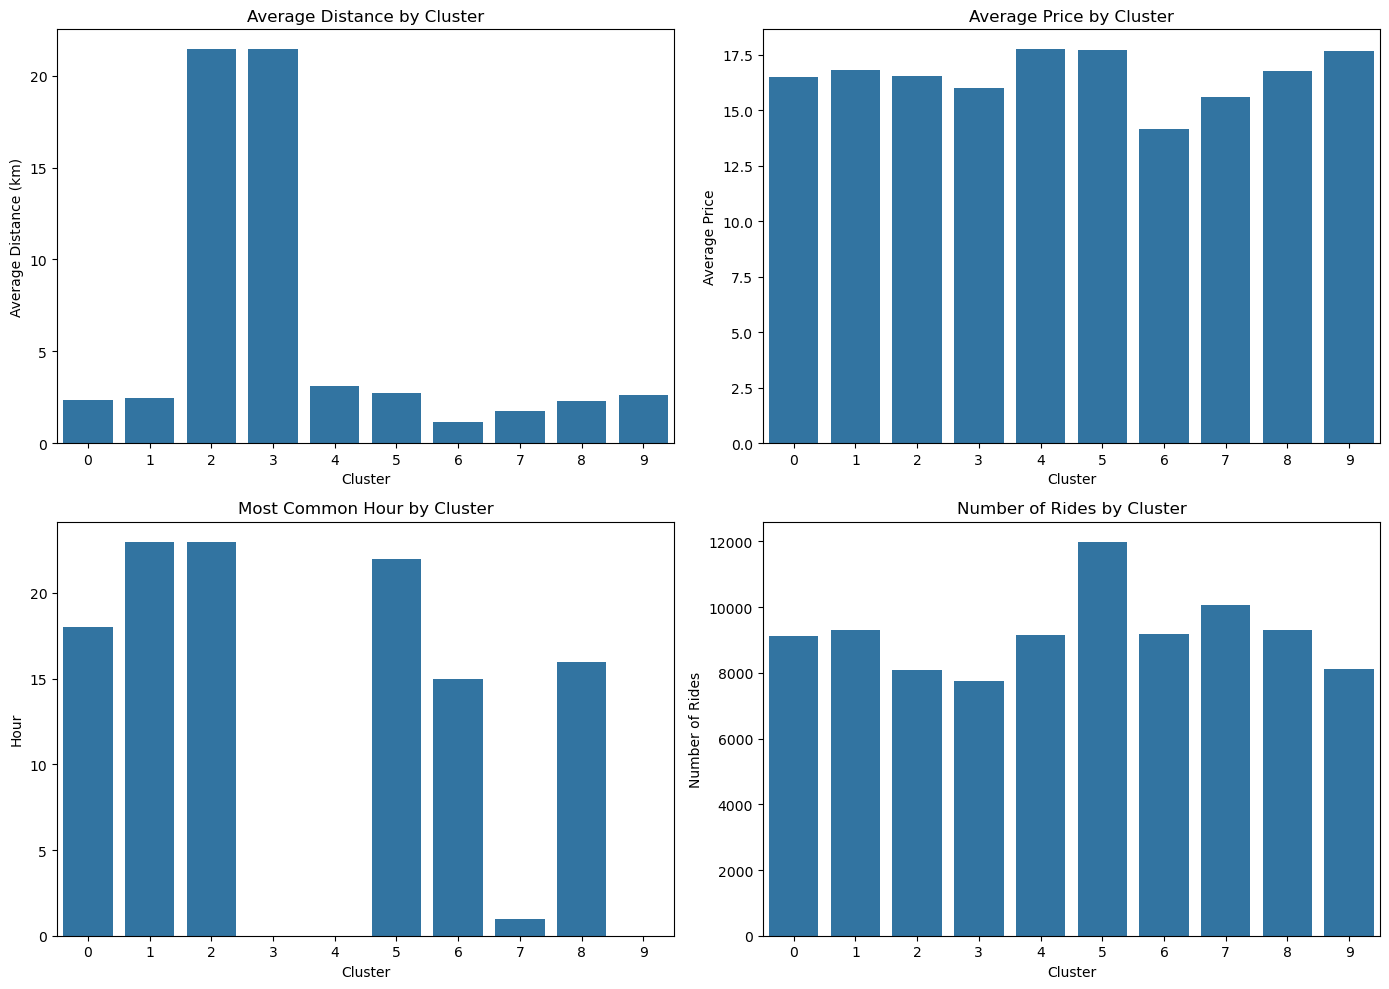

In [73]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 10)
)

sns.barplot(
    x=mobility_profiles.index,
    y=mobility_profiles['average_distance_km'],
    ax=axes[0, 0]
)

axes[0, 0].set_title(
    "Average Distance by Cluster"
)

axes[0, 0].set_xlabel("Cluster")
axes[0, 0].set_ylabel("Average Distance (km)")


sns.barplot(
    x=mobility_profiles.index,
    y=mobility_profiles['average_price'],
    ax=axes[0, 1]
)

axes[0, 1].set_title(
    "Average Price by Cluster"
)

axes[0, 1].set_xlabel("Cluster")
axes[0, 1].set_ylabel("Average Price")


sns.barplot(
    x=mobility_profiles.index,
    y=mobility_profiles['most_common_hour'],
    ax=axes[1, 0]
)

axes[1, 0].set_title(
    "Most Common Hour by Cluster"
)

axes[1, 0].set_xlabel("Cluster")
axes[1, 0].set_ylabel("Hour")


sns.barplot(
    x=mobility_profiles.index,
    y=mobility_profiles['number_of_rides'],
    ax=axes[1, 1]
)

axes[1, 1].set_title(
    "Number of Rides by Cluster"
)

axes[1, 1].set_xlabel("Cluster")
axes[1, 1].set_ylabel("Number of Rides")

plt.tight_layout()
plt.show()

# Streamlit

## Save Models and Preprocessing Objects

In [74]:
import joblib
import os

os.makedirs(
    "streamlit_artifacts",
    exist_ok=True
)

joblib.dump(
    xgb_model,
    "streamlit_artifacts/xgb_model.pkl"
)

joblib.dump(
    scaler,
    "streamlit_artifacts/price_scaler.pkl"
)
    
joblib.dump(
    encoder,
    "streamlit_artifacts/onehot_encoder.pkl"
)

joblib.dump(
    source_encoder,
    "streamlit_artifacts/source_encoder.pkl"
)

joblib.dump(
    destination_encoder,
    "streamlit_artifacts/destination_encoder.pkl"
)

joblib.dump(
    kmeans_model,
    "streamlit_artifacts/kmeans_model.pkl"
)

joblib.dump(
    cluster_scaler,
    "streamlit_artifacts/cluster_scaler.pkl"
)

joblib.dump(
    mobility_profiles,
    "streamlit_artifacts/mobility_profiles.pkl"
)

joblib.dump(
    location_coordinates,
    "streamlit_artifacts/location_coordinates.pkl"
)

joblib.dump(
    list(X_train.columns),
    "streamlit_artifacts/model_features.pkl"
)

print(
    "All Streamlit artifacts were saved successfully."
)

All Streamlit artifacts were saved successfully.
